In [1]:
get_ipython().run_line_magic('matplotlib', 'inline')
import sys, platform, json, importlib.metadata, torch
assert not torch.cuda.is_available(), 'CPU teaching lane unexpectedly sees CUDA'
identity = dict(executable=sys.executable, prefix=sys.prefix, python=platform.python_version(), platform=platform.platform(), cuda_available=torch.cuda.is_available(), torch_cuda_build=torch.version.cuda, packages={name:importlib.metadata.version(name) for name in ['torch','numpy','matplotlib','nbformat','nbclient','ipykernel','transformers','tokenizers','peft']})
print('__DONGXI_KERNEL_IDENTITY__:' + json.dumps(identity, sort_keys=True))

__DONGXI_KERNEL_IDENTITY__:{"cuda_available": false, "executable": "/tmp/dongxi-course-reproduction.ZfVaEu/venv/bin/python", "packages": {"ipykernel": "7.4.0", "matplotlib": "3.10.8", "nbclient": "0.11.0", "nbformat": "5.11.1", "numpy": "2.5.3", "peft": "0.20.0", "tokenizers": "0.23.2", "torch": "2.14.1+cpu", "transformers": "5.18.0"}, "platform": "Linux-6.17.0-1031-nvidia-aarch64-with-glibc2.39", "prefix": "/tmp/dongxi-course-reproduction.ZfVaEu/venv", "python": "3.12.14", "torch_cuda_build": null}


# Teacher attempts and matched rejection SFT

Can choosing better teacher answers improve a student without silently changing what it sees? This original CPU lesson follows every programmatic attempt through filtering and selection, then examines actual tiny sequence students. The teacher is not an API, pretrained model, or human source.

Predict before each reveal. Runnable answers follow the questions. Saved previews are fixed measured references; change a control and rerun its plot to see the current result. The full recipe, raw rejected attempts and negative student outcomes remain in the linked specification and report.

In [2]:
from pathlib import Path
import sys, json, tempfile
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import torch
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'src/dongxi_llms').is_dir())
sys.path.insert(0, str(ROOT/'src'))
from dongxi_llms.teacher_data_lab import load_protocol, filter_pool, select_datasets, fit_student, training_batch, SPECIAL
torch.set_num_threads(1)
protocol = load_protocol(ROOT)
report = json.loads((ROOT/'experiments/reports/2026-10-04-teacher-data.json').read_text())
result = report['results']
pool, selection, runs = result['pool'], result['selection'], result['runs']
assert len(runs) == 9 and not result['failures']
colors = {'top':'#2875a5', 'random':'#af743c', 'length_random':'#77719a'}
plt.rcParams.update({'font.family':'DejaVu Sans','axes.spines.top':False,'axes.spines.right':False})
print(report['environment'])
print('Historical measured source:', report['source_sha256']['src/dongxi_llms/teacher_data_lab.py'])
print('Attempts:', result['journal']['attempts'], 'pool candidates:', len(pool['candidates']))

{'python': '3.12.14', 'torch': '2.14.1+cpu', 'platform': 'Linux-6.17.0-1031-nvidia-aarch64-with-glibc2.39', 'prefix': '/tmp/dongxi-course-reproduction.ZfVaEu/venv', 'executable': '/tmp/dongxi-course-reproduction.ZfVaEu/venv/bin/python', 'device': 'cpu', 'dtype': 'float64', 'threads': 1}
Historical measured source: d28fa327dbf6a50a7f50985217bd721c6c45012eaf44081aa163a1f0583086c2
Attempts: 108 pool candidates: 36


## 1 Where does supervision come from

Predict: if the teacher emits a wrong but well-formed answer, should a format audit accept it? Our declared answer is yes. Correctness is a separate executable training-task score, so a seeded-random control can still select a wrong candidate. Trace text stays in provenance, not in the student loss.

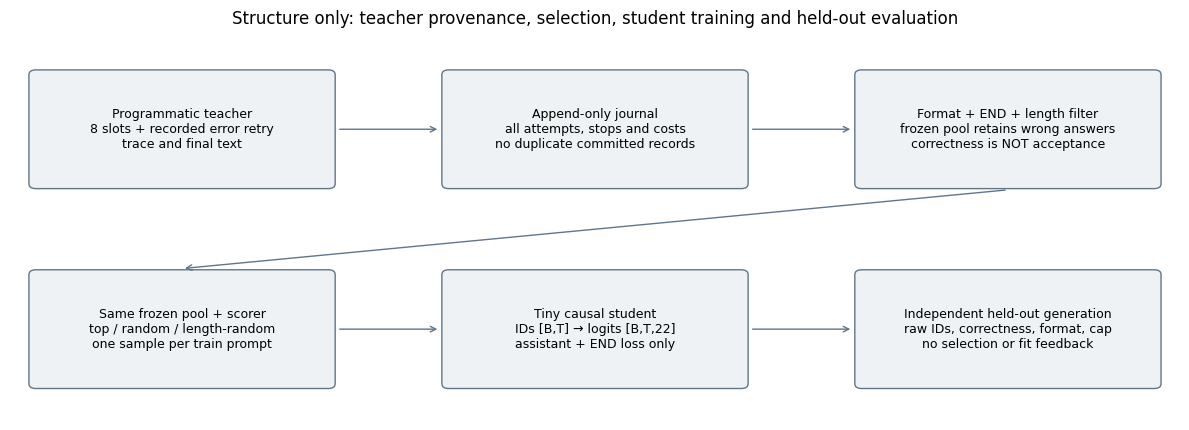

In [3]:
fig, ax = plt.subplots(figsize=(12,4.4))
ax.set(xlim=(-1,5.8),ylim=(-.4,2.8)); ax.axis('off')
nodes = [
(0,2,'Programmatic teacher\n8 slots + recorded error retry\ntrace and final text'),
(2.4,2,'Append-only journal\nall attempts, stops and costs\nno duplicate committed records'),
(4.8,2,'Format + END + length filter\nfrozen pool retains wrong answers\ncorrectness is NOT acceptance'),
(0,.35,'Same frozen pool + scorer\ntop / random / length-random\none sample per train prompt'),
(2.4,.35,'Tiny causal student\nIDs [B,T] → logits [B,T,22]\nassistant + END loss only'),
(4.8,.35,'Independent held-out generation\nraw IDs, correctness, format, cap\nno selection or fit feedback')]
for x,y,text in nodes:
    ax.add_patch(FancyBboxPatch((x-.85,y-.45),1.7,.9,boxstyle='round,pad=.04',facecolor='#eef2f5',edgecolor='#617689'))
    ax.text(x,y,text,ha='center',va='center',fontsize=9)
for start,end in [((.9,2),(1.5,2)),((3.3,2),(3.9,2)),((4.8,1.5),(0,.85)),((.9,.35),(1.5,.35)),((3.3,.35),(3.9,.35))]:
    ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'->','color':'#617689'})
ax.set_title('Structure only: teacher provenance, selection, student training and held-out evaluation')
plt.tight_layout(); plt.show()

Reading guide: the last box has no arrow back to the scorer or training recipe. The diagonal arrow routes one frozen pool into three selection rules; it is not a gradient.

![Saved teacher and student pipeline](../figures/chapter-08/day-11-04_teacher_attempts_and_matched_rejection_sft-01.png)

## 2 Rejections are evidence rather than discarded history

Predict: do rejection-reason counts sum to rejected attempts? Not necessarily: an error can also have an empty answer and missing END. Show every applicable reason, retain raw records, and make the denominator explicit. The candidate matrix reveals correctness and supervised length separately.

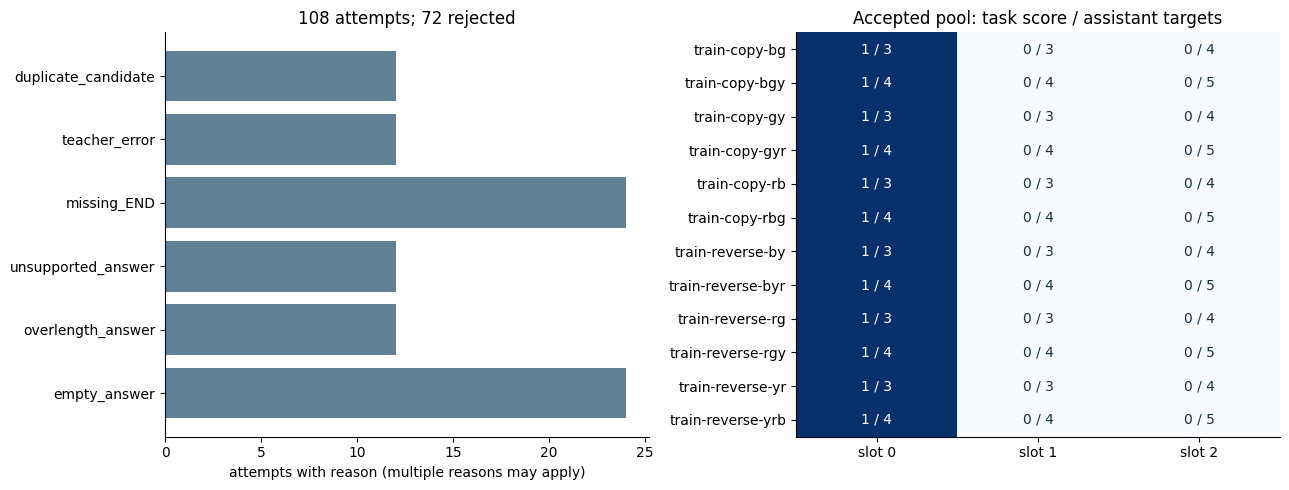

Candidate correctness: {'1': 12, '0': 24}
Teacher cost boundary: {'attempts': 108, 'retry_attempts': 12, 'serialized_words': 966, 'actual_elapsed_seconds': 0.007430077210301533, 'model_forward_calls': 0, 'api_calls': 0}


In [4]:
fig, axes = plt.subplots(1,2,figsize=(13,5))
names = list(pool['reason_counts'])
axes[0].barh(names,[pool['reason_counts'][n] for n in names],color='#617f95')
axes[0].set(xlabel='attempts with reason (multiple reasons may apply)',title=f"{len(pool['audit'])} attempts; {sum(not r['accepted'] for r in pool['audit'])} rejected")
items = sorted({r['item_id'] for r in pool['candidates']})
matrix = np.array([[next(r['score'] for r in pool['candidates'] if r['item_id']==item and r['sample_index']==slot) for slot in (0,1,2)] for item in items])
axes[1].imshow(matrix,vmin=0,vmax=1,cmap='Blues',aspect='auto')
axes[1].set(xticks=range(3),xticklabels=['slot 0','slot 1','slot 2'],yticks=range(len(items)),yticklabels=items,title='Accepted pool: task score / assistant targets')
for i,item in enumerate(items):
    for j,slot in enumerate((0,1,2)):
        row = next(r for r in pool['candidates'] if r['item_id']==item and r['sample_index']==slot)
        axes[1].text(j,i,f"{row['score']} / {row['supervised_tokens']}",ha='center',va='center',color='white' if row['score'] else '#173041')
plt.tight_layout(); plt.show()
print('Candidate correctness:', pool['candidate_correctness'])
print('Teacher cost boundary:', pool['cost'])

Exercise: inspect the retained `attempts.jsonl` retry after a teacher error. The retry emits a duplicate correct final answer, so it has execution cost but supplies no additional unique candidate. Unsupported symbols remain in raw text even though their symbolic IDs are unavailable.

![Saved rejection and candidate audit](../figures/chapter-08/day-11-04_teacher_attempts_and_matched_rejection_sft-02.png)

## 3 Which budgets are actually matched

Predict: does one answer per prompt guarantee equal token exposure? The primary random control can select the extra-word response. The length-random sensitivity samples from the same pool at the top answer's target length. In this fixture each such stratum contains both a correct and a wrong answer; it is not a disguised correctness filter.

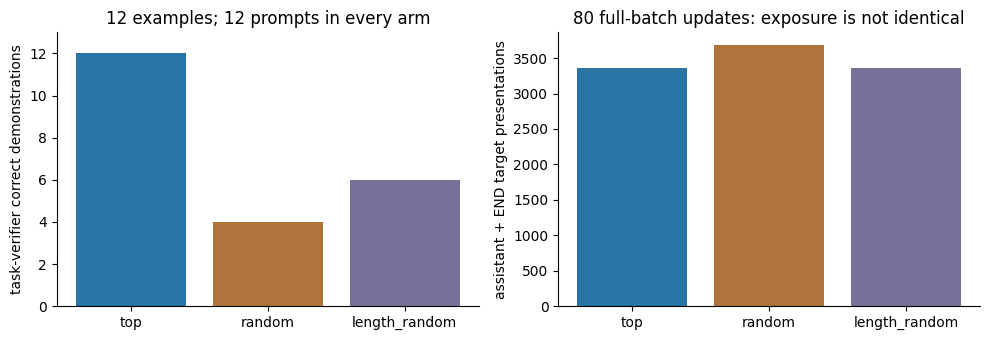

{'top': {'samples': 12, 'prompts': 12, 'train_prompts': 12, 'source_groups': 12, 'families': {'copy': 6, 'reverse': 6}, 'prompt_coverage': 1.0, 'supervised_tokens': 42, 'correct': 12, 'difficulty': {'two-word': 6, 'three-word': 6}, 'length_counts': {'3': 6, '4': 6}, 'excluded_prompt_ids': []}, 'random': {'samples': 12, 'prompts': 12, 'train_prompts': 12, 'source_groups': 12, 'families': {'copy': 6, 'reverse': 6}, 'prompt_coverage': 1.0, 'supervised_tokens': 46, 'correct': 4, 'difficulty': {'two-word': 6, 'three-word': 6}, 'length_counts': {'4': 6, '5': 2, '3': 4}, 'excluded_prompt_ids': []}, 'length_random': {'samples': 12, 'prompts': 12, 'train_prompts': 12, 'source_groups': 12, 'families': {'copy': 6, 'reverse': 6}, 'prompt_coverage': 1.0, 'supervised_tokens': 42, 'correct': 6, 'difficulty': {'two-word': 6, 'three-word': 6}, 'length_counts': {'3': 6, '4': 6}, 'excluded_prompt_ids': []}}
Length-stratum availability: []


In [5]:
arms = ['top','random','length_random']
fig, axes = plt.subplots(1,2,figsize=(10,3.5))
axes[0].bar(arms,[selection['summaries'][a]['correct'] for a in arms],color=[colors[a] for a in arms])
axes[0].set(ylabel='task-verifier correct demonstrations',ylim=(0,13),title='12 examples; 12 prompts in every arm')
axes[1].bar(arms,[selection['summaries'][a]['supervised_tokens']*protocol['student']['updates'] for a in arms],color=[colors[a] for a in arms])
axes[1].set(ylabel='assistant + END target presentations',title='80 full-batch updates: exposure is not identical')
plt.tight_layout(); plt.show()
print(selection['summaries'])
assert all(s['eligible']==2 and s['score_values']==[0,1] for s in selection['length_strata'].values())
print('Length-stratum availability:', selection['length_stratum_unavailable'])

Interpretation: equal model settings and update counts do not repair unmatched supervision. The top/length-random comparison controls target exposure here; the primary random comparison reports its difference explicitly. This is one fixed selection seed, not a broad statistical comparison of selection methods.

![Saved matched and unmatched budgets](../figures/chapter-08/day-11-04_teacher_attempts_and_matched_rejection_sft-03.png)

## 4 Global selection can change the question distribution

Predict: if all correct candidates tie on correctness, what does a shorter-answer tie-break do to global top6? It can select only two-word prompts. Global selection is audited here, not secretly trained as another arm. Compare different global sample budgets without calling them a matched student experiment.

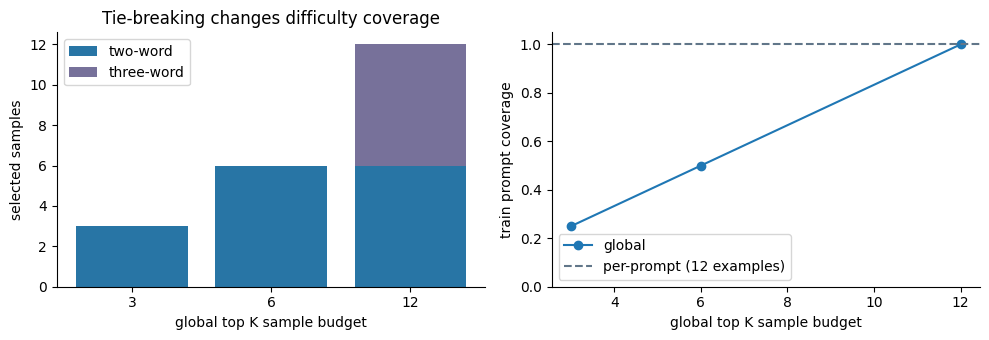

Global top6 excluded prompts: ['train-copy-bgy', 'train-copy-gyr', 'train-copy-rbg', 'train-reverse-byr', 'train-reverse-rgy', 'train-reverse-yrb']


In [6]:
counts = [int(k) for k in selection['global']]
easy = [selection['global'][str(k)]['difficulty'].get('two-word',0) for k in counts]
hard = [selection['global'][str(k)]['difficulty'].get('three-word',0) for k in counts]
fig, axes = plt.subplots(1,2,figsize=(10,3.5))
axes[0].bar([str(k) for k in counts],easy,label='two-word',color='#2875a5')
axes[0].bar([str(k) for k in counts],hard,bottom=easy,label='three-word',color='#77719a')
axes[0].set(xlabel='global top K sample budget',ylabel='selected samples',title='Tie-breaking changes difficulty coverage'); axes[0].legend()
axes[1].plot(counts,[selection['global'][str(k)]['prompt_coverage'] for k in counts],marker='o',label='global')
axes[1].axhline(1,color='#617689',linestyle='--',label='per-prompt (12 examples)')
axes[1].set(xlabel='global top K sample budget',ylabel='train prompt coverage',ylim=(0,1.05)); axes[1].legend()
plt.tight_layout(); plt.show()
print('Global top6 excluded prompts:', selection['global']['6']['excluded_prompt_ids'])

![Saved global coverage audit](../figures/chapter-08/day-11-04_teacher_attempts_and_matched_rejection_sft-04.png)

## 5 The student learns answers rather than audit labels

Predict: where does the first answer token receive loss, and does every real END survive padding? This runnable two-update microscope reuses the existing SFT encoder, collator and exactly-once causal shift. It is separate from the stored eighty-update experiment.

In [7]:
batch = training_batch(selection['arms']['top'])
print('input shape:',tuple(batch['input_ids'].shape),'label shape:',tuple(batch['labels'].shape))
assert int((batch['labels'] == SPECIAL['end']).sum()) == 12
assert bool((batch['labels'][~batch['attention_mask']] == -100).all())
small_student, small_fit = fit_student(selection['arms']['top'],protocol,1101,steps=2)
assert small_fit['initial_state_sha256'] != small_fit['final_state_sha256']
print('Two actual updates:', small_fit['history'])
print('Embedding gradient reached:',small_fit['first_backward']['token.weight'] > 0)
print('Q gradient reached:',small_fit['first_backward']['blocks.0.attn.q.weight'] > 0)

input shape: (12, 16) label shape: (12, 16)


Two actual updates: [{'update': 1, 'loss': 3.1127056769744192, 'gradient_norm': 2.243996242181309, 'valid_supervised_tokens': 42}, {'update': 2, 'loss': 2.766416316290853, 'gradient_norm': 2.336026104267581, 'valid_supervised_tokens': 42}]
Embedding gradient reached: True
Q gradient reached: True


## 6 Low demonstration loss is not independent task accuracy

Predict: can a student fit wrong random demonstrations more easily than the correct set? These are all three predeclared seeds, not a selected winner. Compare only NLLs on their own selected datasets as optimization diagnostics, not as a fair common-test ranking.

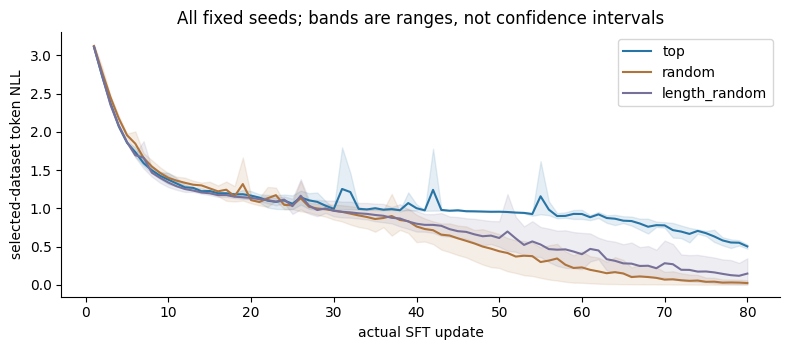

In [8]:
fig, ax = plt.subplots(figsize=(8,3.6))
for arm in arms:
    values = np.array([[p['loss'] for p in r['fit']['history']] for r in runs if r['arm']==arm])
    updates = np.arange(1,values.shape[1]+1)
    ax.plot(updates,values.mean(0),label=arm,color=colors[arm])
    ax.fill_between(updates,values.min(0),values.max(0),color=colors[arm],alpha=.12)
ax.set(xlabel='actual SFT update',ylabel='selected-dataset token NLL',title='All fixed seeds; bands are ranges, not confidence intervals')
ax.legend(); plt.tight_layout(); plt.show()

Reading guide: the datasets differ, so their training losses answer different questions. The raw held-out generation panels below use the same task contract. No recipe was retuned after these outcomes.

![Saved student learning trajectories](../figures/chapter-08/day-11-04_teacher_attempts_and_matched_rejection_sft-05.png)

## 7 Inspect every seed and every held-out failure

Predict: does better teacher selection guarantee the unseen combinations or polite-prefix control? Reveal all outcomes, including zero-correctness rows. A learned END can coexist with a wrong answer or a special token in the body.

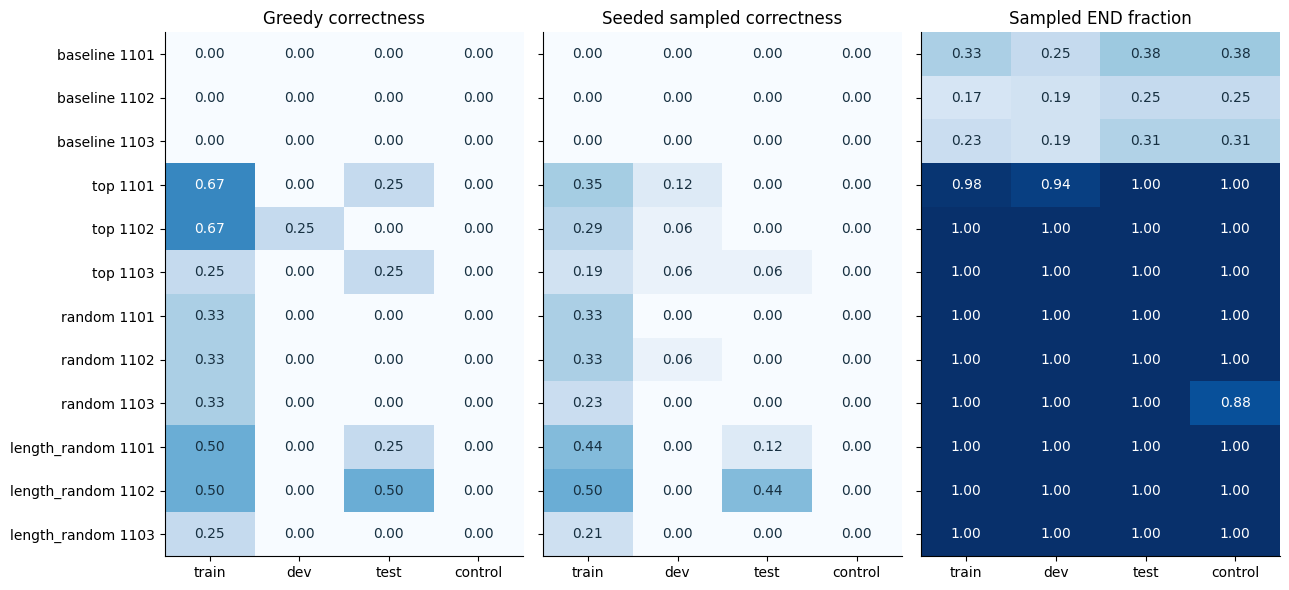

Every final greedy test/control failure: 67
top 1101 test-copy-gr → red green end expected green red stop END
top 1101 test-copy-ybr → red red yellow end expected yellow blue red stop END
top 1101 test-reverse-gry → green green red end expected yellow red green stop END
top 1101 control-copy-br → red red yellow end expected blue red stop END
top 1101 control-reverse-gr → yellow yellow red end expected red green stop END
top 1101 control-copy-byg → end expected blue yellow green stop END
top 1101 control-reverse-ybg → end expected green blue yellow stop END
random 1101 test-copy-gr → yellow blue end expected green red stop END
random 1101 test-reverse-yg → yellow red end expected green yellow stop END
random 1101 test-copy-ybr → blue red yellow end expected yellow blue red stop END
random 1101 test-reverse-gry → yellow green red end expected yellow red green stop END
random 1101 control-copy-br → blue blue green please end expected blue red stop END
random 1101 control-reverse-gr → yell

In [9]:
panels, labels = [], []
for seed in protocol['student']['seeds']:
    row = next(r for r in runs if r['seed']==seed)
    panels.append(row['baseline']); labels.append(f'baseline {seed}')
for arm in arms:
    for row in runs:
        if row['arm']==arm:
            panels.append(row['after']); labels.append(f"{arm} {row['seed']}")
splits = ['train','dev','test','control']
fig, axes = plt.subplots(1,3,figsize=(13,6))
for ax,(mode,metric,title) in zip(axes,[('greedy','correct','Greedy correctness'),('sampled','correct','Seeded sampled correctness'),('sampled','natural_END','Sampled END fraction')]):
    values = np.array([[p['summaries'][s+'/'+mode][metric] for s in splits] for p in panels])
    ax.imshow(values,vmin=0,vmax=1,cmap='Blues',aspect='auto')
    ax.set(xticks=range(4),xticklabels=splits,yticks=range(len(labels)),yticklabels=labels if ax is axes[0] else [],title=title)
    for i in range(len(labels)):
        for j in range(4): ax.text(j,i,f'{values[i,j]:.2f}',ha='center',va='center',color='white' if values[i,j]>.6 else '#173041')
plt.tight_layout(); plt.show()
negative = [r for run in runs for r in run['after']['rows'] if r['split'] in ('test','control') and r['mode']=='greedy' and not r['correct']]
print('Every final greedy test/control failure:', len(negative))
for row in negative:
    print(row['arm'],row['seed'],row['item_id'],'→',row['raw_text'],'expected',row['reference'],'stop',row['stop'])

![Saved all-seed student outcomes](../figures/chapter-08/day-11-04_teacher_attempts_and_matched_rejection_sft-06.png)

The test/control splits each have only four prompts. Programmatic faults are not iid language-model samples, and generated traces do not establish faithful reasoning. This lesson verifies journaling, filtering, matched controls and actual sequence training; it does not prove that top-ranked teacher data universally wins.

[Specification](../../experiments/specs/2026-10-04-teacher-data.md) · [Raw report](../../experiments/reports/2026-10-04-teacher-data.json) · [Interpretation](../../experiments/reports/2026-10-04-teacher-data.md) · [Chapter 8](../../book/chapters/08-instruction-data-as-an-interface.md)